# Car Prize Pridiction using Random Forest Regression

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import pickle

### Step 2 Load data set

In [2]:
df = pd.read_csv("cardekho.csv")

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [5]:
df.shape

(8128, 12)

In [6]:
df.describe()


,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


### Step 3 EDA

In [7]:
df.isnull().sum() #missing value

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [8]:
df.duplicated().sum() 

np.int64(1202)

In [10]:
df.dropna(inplace=True) #remove missing value

In [11]:
df.drop("name",axis=1,inplace=True) #drop name column

In [13]:
df["max_power"]=pd.to_numeric(df["max_power"],errors="coerce") #convert max power

In [14]:
df.dropna(inplace=True)

In [16]:
#encoding
le_fuel=LabelEncoder()
le_seller=LabelEncoder()
le_trans=LabelEncoder()
le_owner=LabelEncoder()

df["fuel"]=le_fuel.fit_transform(df["fuel"])
df["seller_type"]=le_seller.fit_transform(df["seller_type"])
df["transmission"]=le_trans.fit_transform(df["transmission"])
df["owner"]=le_owner.fit_transform(df["owner"])

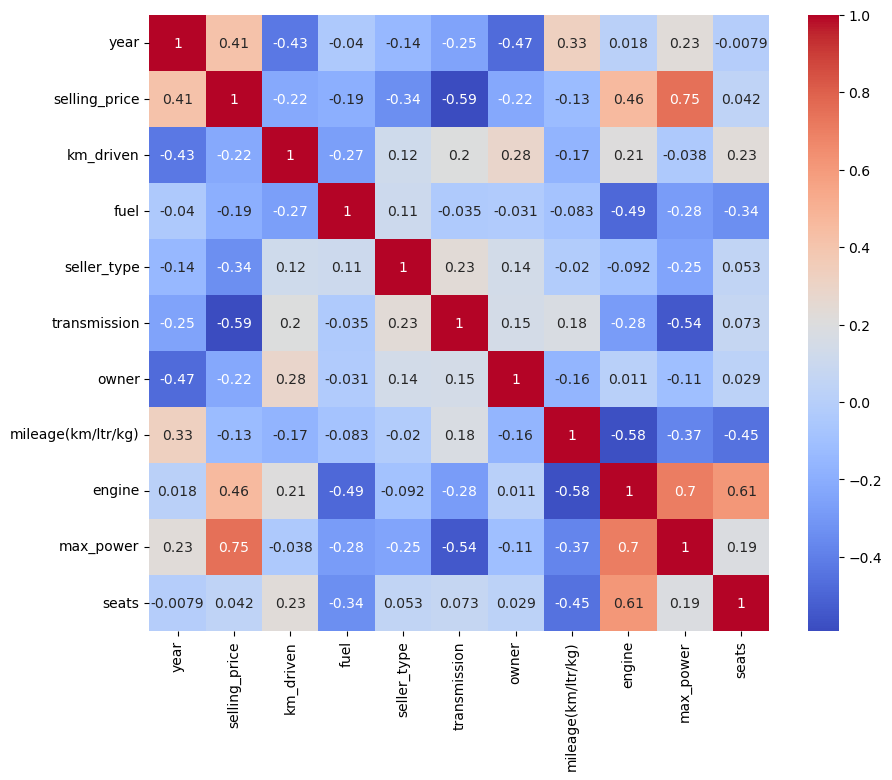

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()       #heatmap

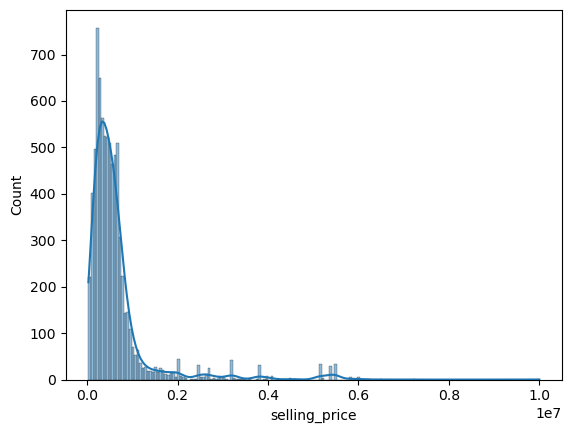

In [20]:
# histogram
sns.histplot(df["selling_price"],kde=True)
plt.show()

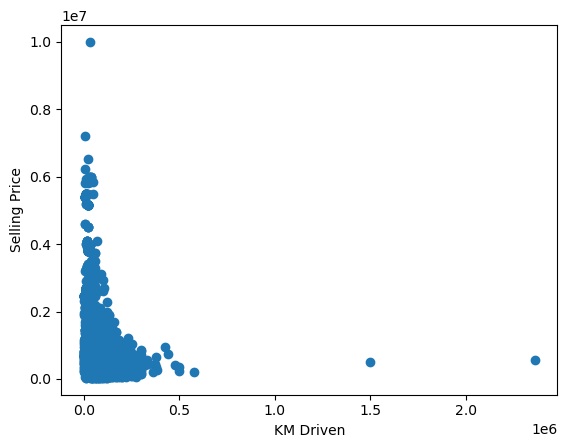

In [21]:
# scatter plot
plt.scatter(df["km_driven"],df["selling_price"])
plt.xlabel("KM Driven")
plt.ylabel("Selling Price")
plt.show()

### Step 4 Target Variables 

In [22]:
X=df.drop("selling_price",axis=1)

y=df["selling_price"]

### Step 5 Train Test Split

In [23]:
X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.20,

random_state=42
)

### Step 6 Import Model

In [24]:
model=RandomForestRegressor(

n_estimators=100,

random_state=42

)

### Step 7 Training

In [25]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Step 8 Prediction 

In [26]:
y_pred=model.predict(X_test)

### Step 9 Evaluation Matrix

In [27]:
print("R2 Score :",r2_score(y_test,y_pred))

print("MAE :",mean_absolute_error(y_test,y_pred))

mse=mean_squared_error(y_test,y_pred)

print("MSE :",mse)

rmse=np.sqrt(mse)

print("RMSE :",rmse)

R2 Score : 0.9837709756270491
MAE : 61205.65202265765
MSE : 11283765411.117638
RMSE : 106225.06959808328


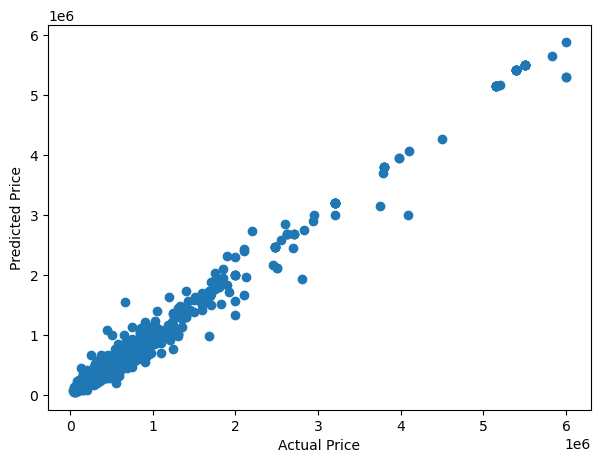

In [28]:
# actual vs predicted
plt.figure(figsize=(7,5))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.show()

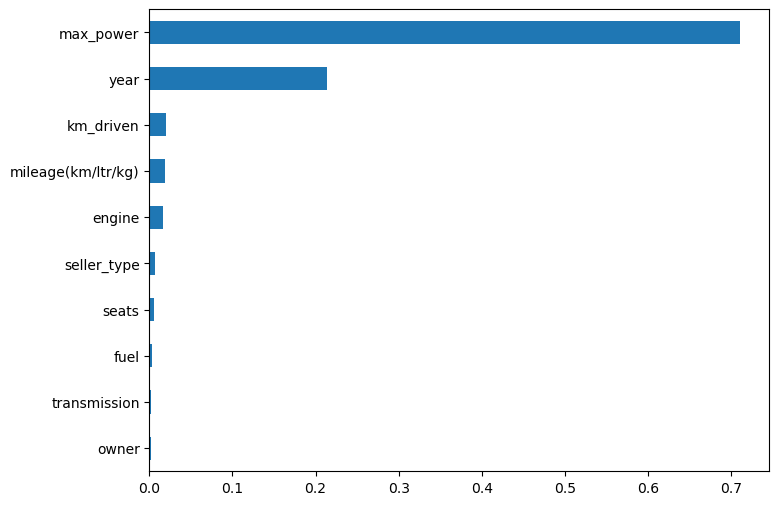

In [29]:
importance=pd.Series(

model.feature_importances_,

index=X.columns

)

importance.sort_values().plot(

kind="barh",

figsize=(8,6)

)

plt.show()

### Step 10 Convert Model into PKL file 

In [31]:
pickle.dump(

model,

open("car_price_model.pkl","wb")
)
print("pkl successfully")

pkl successfully


### GUI